# 0 Präambel

Group 8: 
Yuetong Jin
Simon Andres
Christopher Forschner
Felix Bunse
Janik Müller

Download data
import packages
define signal functions
define portfolio etc

In [1]:
#### Importing the libraries -------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data

#### DOWNLOAD DATA -----------------------------------------

# only change the equity ticker strings if required
# don't change the variable name "tickers"
tickers = [ \
    'AAPL', # Apple
    'MSFT', # Microsoft
    'AMZN', # Amazon
    '^GSPC'] # S&P500 - Benchmark

# only change string values if required
# don't change the two variable names "start_date" and "end_date"
start_date = '2010-01-01'
end_date = '2021-12-31'

# download the time series of adj. close price
# for each of the tickers from Yahoo finance
# in case you receive an error go through this:
## https://stackoverflow.com/questions/74832296/typeerror-string-indices-must-be-integers-when-getting-data-of-a-stock-from-y
price_data = {}

for ticker in tickers:
    price_data[ticker] = yf.download(ticker, start=start_date, end=end_date)['Adj Close']

# create dataframe with one row per day and adj. close price for each of the tickers
# and dataframe with price changes
df_prices = pd.concat([price_data[ticker].rename(ticker) for ticker in tickers], axis=1)
prev = df_prices.to_numpy()
prev = prev / np.insert(prev[:-1,:], 0, np.ones(prev.shape[1]), 0)
prev[0] = np.ones(prev.shape[1])
df_price_changes = df_prices.copy(deep=True)
df_price_changes[:] = prev


#### DEFINE HELPER FUNCTIONS -------------------------------------------------

# Moving average
def moving_average(prices, window_length):
    return np.convolve(prices, np.ones(window_length)/window_length, mode='same')

# Standard Deviation
def standard_deviation(prices, window_length):
    avg = moving_average(prices, window_length)
    return np.sqrt(np.convolve((prices - avg)**2, np.ones(window_length)/window_length, mode='same'))


# Calculate the Differnce in Percent

def diff(array): 

    diffs = np.zeros(len(array))
    for i in range(0, len(array)):
        if i == 0:
            diffs[i] = 0
        else:
            diffs[i] = (array[i] - array[i-1]) / array[i-1]
        
    return(diffs)

# Calculate the mean

def mittelwert(array):
    
    # Making sure that the list we calculate is not of length zero 
    if len(array) == 0:
        return None
    else:
        return sum(array) / len(array) # Returning the mean if all the above is incorrect
    
    
# define a helper function for the percental change
def percental_change(cash, window_length):
    cash_np=cash.to_numpy()
    changes=[]
    changes_0=0
    changes.append(changes_0)

    for i in range(1,window_length):
        changes_i=(cash_np[i]-cash[i-1]) * 100 
        changes.append(changes_i)  

    return changes




#### Signals ------------------

### MACD

## Helper function

#create exponential weighted moving average function
#pandas had an own ewm function implemented

def ewm_own(x,s):
    #calculate the weights alpha
    alpha=(2/(1+s))
     #convert the series into a numpy array

    #initalize the first EWM
    ewm_0=x[0]

    exp_mean=[]
    exp_mean.append(ewm_0)
    #calculate the EWM for the series
    for i in range(1,len(x)):
        ewm_i=alpha*x[i]+(1-alpha)*exp_mean[i-1]
        exp_mean.append(ewm_i) 
    return exp_mean 

#create a helper function for the trading strategy (cross over strategy)
def strategy(dataset):    
    buy_price = []
    sell_price = []
    macd_signal = []
    signal = 0

    for i in range(len(dataset)):
        if dataset['MADC'][i] > dataset['signal'][i]: #buy at this point
            if signal != 1:
                buy_price.append(dataset['prices'][i])
                sell_price.append(np.nan)
                signal = 1
                macd_signal.append(signal)
            else: #hold
                buy_price.append(np.nan)
                sell_price.append(np.nan)
                macd_signal.append(0)
        elif dataset['MADC'][i] < dataset['signal'][i]: #sell
            if signal != -1:
                buy_price.append(np.nan)
                sell_price.append(dataset['prices'][i])
                signal = -1
                macd_signal.append(signal)
            else: #hold
                buy_price.append(np.nan)
                sell_price.append(np.nan)
                macd_signal.append(0)
        else: #hold
            buy_price.append(np.nan)
            sell_price.append(np.nan)
            macd_signal.append(0)

    #save in data frame
    trading_strategy = pd.DataFrame({
    'Buy Price': buy_price,
    'Sell Price': sell_price,
    'position_change': macd_signal
},index=dataset.index)
    return trading_strategy

## SIGNAL 

def signal_0(series,short_window = 12, long_window = 26, signal_period = 9):
    # Init
    signals = pd.DataFrame(index = series.index)
    
    # Compute exponential moving average
    signals['prices']=series #the prices
    signals['short_ma'] = ewm_own(series, short_window)
    signals['long_ma'] = ewm_own(series, long_window)
    signals['MADC']=signals['short_ma']-signals['long_ma']
    signals['signal']=ewm_own(signals['MADC'],signal_period)
    signals['histogram']=signals['MADC']-signals['signal']

    #compute the signals and trading strategy
    trading_strategy=strategy(signals)
    signal_df=pd.concat([signals,trading_strategy],axis=1)
    return signal_df



### RSI

## Calculate RSI function

def calculate_rsi(prices, period = 14):

    # Calculate the difference between two adjacent prices
    differences = np.diff(prices)
    
    # Create two copies of the differences: One for the up movements and one for the down movements
    positive_differences = differences.copy()
    negative_differences = differences.copy()
    
    # Set all the values below zero in the positive differences array and all the values above zero in the negative differences array to zero
    positive_differences[positive_differences < 0] = 0
    negative_differences[negative_differences > 0] = 0
    
    # Calculate the average gain and loss for the first observation
    average_gain = mittelwert(positive_differences[:period])
    average_loss = -mittelwert(negative_differences[:period])
    
    # Initialize the rsi_values list to store all the coming rsi_values to speed up the code
    rsi_values = np.zeros(len(prices))

    # Calculate the average gain and losses for the the rest of the periods
    for i in range(period, len(prices)):
        current_differences = differences[i - 1]
        if current_differences > 0:
            average_gain = (average_gain * (period - 1) + current_differences) / period
            average_loss = (average_loss * (period - 1)) / period
        else:
            average_gain = (average_gain * (period - 1)) / period
            average_loss = (average_loss * (period - 1) - current_differences) / period
        rs = average_gain / average_loss
        rsi = 100.0 - (100.0 / (1.0 + rs))
        rsi_values[i] = rsi
        rsi_values[rsi_values == 0] = np.nan

    return rsi_values.tolist()

## Calculating the RSI - Signal

def signal_1(data, window = 14, upper_bound = 70, lower_bound = 30):
    
    data_rsi = pd.DataFrame(index = data.index)
    
    data_rsi['Close Price'] = data
    
    # Calculate RSI for the observed stock data
    data_rsi['rsi_values'] = calculate_rsi(data_rsi['Close Price'], window)

    # Generate a list to store the position changes according to RSI values
    position_change = [0] * len(data_rsi['Close Price'])
    
    
    # Ensure that there are no sell signals before a buy signal and that the first signal is a buy signal
    # Initial value of holding stock is 'no'
    holding = 'no'
    
    for i in range(len(data)):
        if data_rsi['rsi_values'][i] < lower_bound and holding == 'no': # this is our buy condition
            
            position_change[i] = 1 # adjusting position change to 1
            holding = 'yes' # changing the holding parameter to: 'yes'
            
        elif data_rsi['rsi_values'][i] > upper_bound and holding == 'yes': # this is our sell condition
            
            position_change[i] = -1 # adjusting the position to -1
            holding = 'no'# changing the holding parameter to: 'no'
            
        else:
            position_change[i] = 0 # here we just make sure, that all other values are zeros
            
    data_rsi['position_change'] = position_change
    
    # Signal Column -> when to buy and sell
    
    data_rsi['signal_buy'] = np.where(data_rsi['rsi_values'] < lower_bound, 1, 0)
    data_rsi['signal_sell'] = np.where(data_rsi['rsi_values'] > upper_bound, -1, 0)
            
    # Signal that says when we hold the asset - 'Position Open'
    
    data_rsi['signal'] = np.cumsum(data_rsi['position_change'])

    return data_rsi



### Bollinger Bands 

def signal_2(series, window_length=20, num_std=2):

    # Compute middle band (SMA), upper band and lower band
    rolling_mean = moving_average(series, window_length)
    rolling_std  = standard_deviation(series, window_length)
    upper_band = rolling_mean + (rolling_std*num_std)
    lower_band = rolling_mean - (rolling_std*num_std)

    # Create a DataFrame to store all data
    signals = pd.DataFrame(index=series.index)
    signals['Middle Band'] = rolling_mean
    signals['Upper Band'] = upper_band
    signals['Lower Band'] = lower_band
    
    # Create signals based on Bollinger Bands and SMA
    # We make sure not to generate sell signals before a buy signal
    signals['signal'] = 0.0
    holding = False
    for i in range(window_length, len(series) - 1):  # Need to look ahead 1 day, so stop loop 1 day early
        # If price crosses above the lower band, we enter a position
        if not holding and series[i-1] <= lower_band[i-1] and series[i] > lower_band[i]:
            signals['signal'][i+1] = 1.0
            holding = True
        # If we are holding a position and price crosses above the SMA from below, we exit the position
        elif holding and series[i-1] <= rolling_mean[i-1] and series[i] > rolling_mean[i]:
            signals['signal'][i+1] = 0.0
            holding = False
        # If we are holding a position and price doesn't cross above the SMA, we hold the position
        elif holding and series[i] <= rolling_mean[i]:
            signals['signal'][i+1] = 1.0

    signals['position_change'] = signals['signal'].diff()
    signals.loc[series.index[0], 'position_change'] = 0
    
    return signals


#### Combining the Signals ------------------------------------

# Compute signals
signals = {}
signals[tickers[0]] = signal_0(df_prices[tickers[0]])
signals[tickers[1]] = signal_1(df_prices[tickers[1]])
signals[tickers[2]] = signal_2(df_prices[tickers[2]])
df_position_open = pd.concat([
    signals[tickers[0]]['signal'].rename(tickers[0]),
    signals[tickers[1]]['signal'].rename(tickers[1])], axis = 1)
df_position_changes = pd.concat([
    signals[tickers[0]]['position_change'].rename(tickers[0]),
    signals[tickers[1]]['position_change'].rename(tickers[1]),
    signals[tickers[2]]['position_change'].rename(tickers[2])], axis = 1)



#### Portfolio Building ---------------------------------------

# ALLOCATE CAPITAL AND COMPUTE RESULTING POSITIONS
initial_cash = 1.0
capital_fraction_per_trade = 0.35

# DO NOT MODIFY THIS CELL BELOW THIS LINE
position = []

def open_trades(position, position_change):
    vec = np.maximum([position_change[ticker] for ticker in tickers[:-1]], [0])
    vec = position[-1] * (1 - np.power((1 - capital_fraction_per_trade), np.sum(vec))) * vec / (1 if (np.nansum(vec) == 0.0) else np.nansum(vec))
    return np.append(vec + position[:-1], position[-1] - np.sum(vec))

def hold_trades(position, price_change):
    return np.concatenate((position[:-1] * price_change[:-1], [position[-1]]))

def close_trades(position, position_change):
    vec = np.concatenate((np.array([position_change[ticker] < 0.0 for ticker in tickers[:-1]]), [False]))
    position[-1] = position[-1] + np.sum(position[vec])
    position[vec] = 0.0
    return position
    
is_first = True
for idx, position_change in df_position_changes.iterrows():
    if is_first:
        position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
        is_first = False
    else:
        hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
        hlpr_pos = close_trades(hlpr_pos, position_change)
        position.append(open_trades(hlpr_pos, position_change))

df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])



#### Meaningful Statistics ---------------------------------------

# COMPUTE MEANINGFUL STATISTICS OF YOUR STRATEGY
# YOU ARE FREE TO CHOOSE MEASURES

# REMEMBER THAT YOU MAY NOT USE READY-TO-USE FUNCTIONS
# WHEN IN DOUBT - CODE A FUNCTION ON YOUR OWN!
# EXAMPLE: .mean() and .std() are ready-to-use, that's why they are implemented below

returns = df_position.sum(axis=1)
returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
mean_returns = np.sum(returns) / len(returns)
std_returns = np.sqrt(np.sum(np.square(returns - mean_returns)) / len(returns))
print('Annualized mean: ' + str(mean_returns * 250))
print('Annualized std:  ' + str(std_returns * np.sqrt(250)))


KeyboardInterrupt



<hr>

# 1 Introduction into Trading Signals

Financial trading is a dynamic and intricate practice that involves buying and selling financial instruments such as stocks, bonds, commodities, or currencies in order to generate profits. In our case we are looking at the stocks of: _Apple, MIcrosoft and Amazon_. Traders employ a wide range of strategies and tools to make informed decisions about when to enter or exit positions in the market. All of this is done in order to beat the average return of the market portfolio and to gain from the fluctuations of the prices.
In this research notebook, we will explore three popular trading signals: Moving Average Convergence Divergence (MACD), Relative Strength Index (RSI), and Bollinger Bands, which assist traders in identifying potential trading opportunities.

MACD, RSI, and Bollinger Bands are widely used technical indicators in financial trading. These signals provide valuable insights into the market's momentum, overbought or oversold conditions, and volatility, respectively. By analyzing these indicators, traders aim to capture potential trends, reversals, or price breakouts, enabling them to make timely and well-informed trading decisions.

The primary objective of trading is to generate profits by taking advantage of price movements in financial markets. Traders aim to buy an asset at a lower price and sell it at a higher price (in case of long positions), or sell an asset at a higher price and buy it back at a lower price (in case of short positions). The utilization of trading signals like MACD, RSI, and Bollinger Bands can assist traders in identifying favorable entry and exit points, improving the probability of successful trades and overall returns.

Implementing trading signals requires comprehensive research and analysis. Traders need to delve into historical price data, study market trends, and understand the underlying principles of each indicator. In order to achieve this we will analyze financial literature and perform an own parameter optimization for our trading signals.
This research provides us with a solid foundation for implementing these trading signals effectively and increases the likelihood of making informed trading decisions and therefore outperform the market in different risk and return measures.

Financial trading encompasses a vast array of strategies, techniques, and tools. While MACD, RSI, and Bollinger Bands are valuable indicators, it's important to note that no single signal guarantees trading success.
The following notebook is structured as follows, first we are explaining the theoretical background of the trading signals, then we will perform our parameter optimization asnd with the optimal parameters we will analyze the trades of our trading signals graphically.

<hr>

# 2 Signals and theoretical Background

## 2.1 Moving Average Convergence/Divergence (MACD)


Wang,J; Kim,J. (2018). Predicting Stock Price Trend Using MACD Optimized by Historical Volatility. Published: Mathematical Problems in Engineering. pp.1-12. Available at: 
https://www.hindawi.com/journals/mpe/2018/9280590/

Appel,G.; Dobson, E. (2008). Understanding MACD. Published: Traders Press, Inc. Available at: https://www.scribd.com/document/349277765/Understanding-MACD#


Kang, B. (2021). Improving MACD Technical Analysis by Optimizing Parameters and Modifying Trading Rules: Evidence from the Japanese Nikkei 225 Futures Market. Published: Journal of Risk and Financial Management. Volume 14. Available at: 
https://www.mdpi.com/1911-8074/14/1/37


Introduced by Appel in the year 1979, the MACD is one of the most widely used indicators in technical analysis because it is considered to be one of the most effective indicators for defining a trend. Another reason for it's widely use is it's relative easy implementation compared to different indicators. The main idea of the MACD is to examine the relation ship between two moving price averages. In the following, The construction of the MACD is explained in more detail.

In general the MACD is obtained by subrtractin a longer term exponential moving average (EMA) from a shorter term exponential moving average of prices. The EMA is defined the following way:
$$ EMA_{t} = \alpha \left(P_{t}-EMA_{t-1}\right)+EMA_{t-1}$$
$$ EMA_{t}=\alpha P_{t}+(1-\alpha)EMA_{t-1}$$
Here, $\alpha=\frac{2}{n+1}$ represents the weight of the price compared to the EMA of the previous period. Furthermore, it has to be mentioned that the enumarator is set to two to give more weight to the present period. $n $ is the time span under observation. Since we subtract EMA's from two different periods, we can present the two EMAs as follows:

$$EMA_{t} (n_{1})=\alpha P_{t}+(1-\alpha)EMA_{t-1} (n_{1})$$

$$EMA_{t} (n_{2})=\alpha P_{t}+(1-\alpha)EMA_{t-1} (n_{2})$$
 
Using the equations above, the three elements of the MACD indicator can be calculated as follows:

$$ MACD_{t} \left(n_{1}, n_{2}\right)=EMA_{t} \left(n_{1}\right)-EMA_{t} \left(n_{2}\right)$$

$$signal_{t} (n_{3})=\alpha MACD_{t}+(1-\alpha)MACD_{t-1} (n_{2})$$

$$ Histogram_{t} = MACD_{t} - Signal_{t}$$

where MACD is the difference between the two different EMA's. The signal then simply denotes the period for the EMA calculation of the MACD series. The Histogram is used for the graphical representation of the distance between the MACD and signal line.

Stocks are bought after two trading rules. The first trading rule used is called "zero crossover" :

$$
     zero\ crossover=\left\{\begin{array}{ll} Buy, when\ MACD_{t}\left(t_{1},t_{2}\right)=EMA_{t}\left(t_{1}\right)-EMA_{t}\left(t_{2}\right) >0\\
         Sell, when\ MACD_{t}\left(t_{1},t_{2}\right)=EMA_{t}\left(t_{1}\right)-EMA_{t}\left(t_{2}\right) <0  \end{array}\right.$$
In this rule, the trader buys or sells the stock as soon as the MACD crosses zero the first time.  The second rule which is called "signal line crossover" is definded as:       
         
$$
     signal\ line\ crossover=\left\{\begin{array}{ll} Buy, when\ Histogram_{t}=MACD_{t}-Signal_{t}>0\\
         Sell, when\ Histogram_{t}=MACD_{t}-Signal_{t} <0  \end{array}\right.$$

In this rule the stock is bought/sold if the Histogram crosses zero.  

The most widely used parameter values are 12, 26, 9 days and are represented as such MACD(12,26,9). The values are based on the working week when Appel introduced it in 1979. In those times the working week consisted of six days and the trading week also consisted of 6 days. Therefore, 12 represents two trading weeks, 26 roundabout one month, and nine one and a half weeks. However, these values are not determined and in the following we will look how the trading signal works in comparison to different schedules.



## 2.2 Relative Strength Index (RSI)

Marek,P; Sediva,B. (2017). Optimizing and Testing of RSI. Published: 11th International Scientific Conference on Financial Management of Firms and Financial Institutions. Available at: 
https://www.researchgate.net/publication/322209653_Optimization_and_Testing_of_RSI

Ng,W; Liew, K; Chong, T. (2014). Revisiting the Performance of MACD and RSI oscillators. Published in Journal of Risk and Financial Management. Volume 7. pp. 1-12. Available at:
https://www.mdpi.com/1911-8074/7/1/1

The RSI is a techincal indicator, which intends to indicate the historical and current weakness or strength of stock or market based on the closing prices in a given time period. By using the RSI one can obtain buy and sell signals. The main goal of the indicator is to capitalize on overbought and oversold zones. The RSI is then calculated as follows:

Relative Strength is calculated as follows:

$RS = \frac{Avg. Gain}{Avg. Loss}$

Relative Strength Index is calculated as follows:

$RSI = 100 - \frac {100}{1+ RS}$

There are different strategies of finding buy and sell signals, however according to our research papers the most efficient rules in our specific scenario are the following: 
- A buy signal is triggered when The RSI crosses the centerline (the fair value of the stock), meaning when the RSI = 50, a sell signal is then triggered when the RSI crosses the centerline from above. We denote this trading rule as RSI(N,50) where N denotes the periods/days. This, however, is not implemented in our trading strategy. We used the second rule.
- The second rule wants to utilize the overbought and oversold areas. A buy signal is triggered when the RSI falls below the oversold zone, meaning RSI < 30, and rises above 30 again. On the other hand, a sell signal is triggered when the RSI rises in the overbought zone, meaning RSI > 70, and then declines to below 70 again. We denote this trading rule as RSI(N, 30/70). Furhter down, we test diffferent window lengths, as well as different over-bought and over-sold zones.
 



## 2.3 Bollinger Bands

Bollinger, J. (1992). Using Bollinger Bands. [online] pp.47–51. Available at: https://c.mql5.com/forextsd/forum/211/Using%20Bollinger%20Bands%20by%20John%20Bollinger.pdf.
    
 &nbsp;&nbsp;&nbsp;&nbsp;Bollinger Bands, created by John Bollinger during the early 1980s, represent a technical trading tool to analyze the investment decisions. They arose from the need for adaptive trading bands and the observation that volatility was dynamic, not static, as was widely believed at the time. Bollinger Bands can be applied in all financial markets, including equities, forex, commodities, and futures. Bollinger Bands are created to answer the question of whether prices are high or low on a relative basis. It can also be used as trading signal.  
&nbsp;&nbsp;&nbsp;&nbsp;Bollinger bands consist of three curves where the middle line is just the simple moving average. As John Bollinger (1992) discussed, for the stock market, a 20-day period is optimal for calculating the Bollinger Bands as the intermediate-term trend. 10-day and 50-day are then optimal for the short-term and long-term trend. To calculate the upper and lower band, taking advantage of the standard deviation is helpful, which could sensitively measure the extreme deviations based on the closing price. Bollinger Bands are then supposed to plot the upper and lower bands by shifting the simple moving average two standard deviations above and below the simple moving average. Calculations are shown as follows:  
$$
SMA_{N}(t)=\frac{\sum_{i=t-t-N+1}^{t}p(i)}{N}
$$
$$
BB_{N}^{high}(t)=SMA_{N}(t)+k\times \sqrt{\frac{\sum_{i=t-N+1}^{t}[p(i)-SMA_{N}(i)]^{2}}{N}} 
$$
$$
BB_{N}^{low}(t)=SMA_{N}(t)-k\times\sqrt{\frac{\sum_{i=t-t-N+1}^{t}[p(i)-SMA_{N}(i)]^{2}}{N}}
$$  
 &nbsp;&nbsp;&nbsp;&nbsp;The trading rules are as follows: <br> 
 &nbsp;&nbsp;&nbsp;&nbsp;Long Position Signal: <br> 
 &nbsp;&nbsp;&nbsp;&nbsp;If $p_{N}(t-1)<  BB_{N}^{low}(t-1) $ and $p_{N}(t)>  BB_{N}^{low}(t) $ , a long position is initiated on the next day's opening. When $p_{N}(t)> SMA_{N}(t) $ , the long position closes on the next day's opening.  
 &nbsp;&nbsp;&nbsp;&nbsp;Short Position Signal: <br> 
  &nbsp;&nbsp;&nbsp;&nbsp;If  $p_{N}(t-1)>  BB_{N}^{high}(t-1) $ and $p_{N}(t)< BB_{N}^{high}(t) $ , a short position is initiated on the next day's opening. When $p_{N}(t)< SMA_{N}(t) $ , the short position closed on the next day's opening. 
<br>&nbsp;&nbsp;&nbsp;&nbsp; where N refers to the time period chosen for calculating the moving average and k refers to the distance of the band from the moving average. As discussed by John Bollinger (1992), it's plausible to adopt k=2 when choosing N=20. 

<hr>

# 3 Empirical Analysis of our Signals

## 3.1 Grid Search for the Optimal Parameters

When developing a trading strategy, it is essential to determine the optimal values for the parameters involved in the strategy. Parameter optimization aims to find the parameter values that maximize the performance or profitability of a trading strategy. The success of our trading strategies is measured by the annualized mean return of our portfolio.
The process of parameter optimization typically involves defining a set of parameter values to explore, evaluating the strategy's performance for each combination of parameter values, and selecting the combination that yields the best results.

One commonly used technique for parameter optimization is grid search, where a predefined grid of parameter values is systematically tested. The strategy's performance is evaluated for each parameter combination within the grid, and the combination that produces the best results is chosen. In our case we use one signal on all three stocks and evaluate the portfolio performance. This is done so that the signal parameters are not overfitted to one particular stock but are chosen depending on three stocks and their combination. Afterwards we are going to look at the fitted partameters and, in combination with our theoretical research, decide which parameter values give us the best prospects for the future.

It's worth noting that parameter optimization is an iterative process that requires careful consideration. Over-optimization, or "over-fitting," should be avoided, as it can lead to strategies that perform well on historical data but fail to generalize to new market conditions. Which is why we will look at the optimized parameter values only in combination with the theoretical values provided above. The performance measure we used in order to gain the optimized parameters was the annualized mean return of our portfolio.

### 3.1.1 MACD-Optimal Parameters

In [ ]:
#find best parameters for MADC
short_params=np.array([6,8,9,12])
long_params=np.array([17,20,23,24,26])
signal_periods=np.array([7,8,9])

combinations_madc=[]
ann_means=[]
for i in short_params:
    for j in long_params:
        for k in signal_periods:
            #compute signal
            signals = {}
            signals[tickers[0]] = signal_0(df_prices[tickers[0]],short_window=i,long_window=j,signal_period=k)
            signals[tickers[1]] = signal_0(df_prices[tickers[1]],short_window=i,long_window=j,signal_period=k)
            signals[tickers[2]] = signal_0(df_prices[tickers[2]],short_window=i,long_window=j,signal_period=k)
            df_position_open = pd.concat([
            signals[tickers[0]]['signal'].rename(tickers[0]),
            signals[tickers[1]]['signal'].rename(tickers[1]),
            signals[tickers[2]]['signal'].rename(tickers[2])], axis = 1)
            df_position_changes = pd.concat([
            signals[tickers[0]]['position_change'].rename(tickers[0]),
            signals[tickers[1]]['position_change'].rename(tickers[1]),
            signals[tickers[2]]['position_change'].rename(tickers[2])], axis = 1)

            #portfolio creation
            position = []
            is_first = True
            for idx, position_change in df_position_changes.iterrows():
                if is_first:
                    position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
                    is_first = False
                else:
                    hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
                    hlpr_pos = close_trades(hlpr_pos, position_change)
                    position.append(open_trades(hlpr_pos, position_change))

            df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])
            returns = df_position.sum(axis=1)
            returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
            ann_mean_returns = (np.sum(returns) / len(returns))*250
            combination_madc_i=f'{i},{j},{k}'
            ann_means.append(ann_mean_returns)
            combinations_madc.append(combination_madc_i)

#store the combinations in a data frame
combinations_madc_df,ann_means_madc=pd.DataFrame(combinations_madc,columns=['combinations']),pd.DataFrame(ann_means,columns=['ann_means'])
combis_madc=pd.concat([combinations_madc_df,ann_means_madc],axis=1)
max_row_index=combis_madc['ann_means'].idxmax()
max_row1=combis_madc.loc[max_row_index]
max_row1

combinations      8,17,9
ann_means       0.119522
Name: 17, dtype: object

For the MACD, the optimal short period is eight days For the long period, the optimal number of days is 17. And the signal period is nine days. These paramters are different from the recommended parameters which are mentioned in the theoretical explanation of the MACD.

### 3.2.2 RSI-Optimal Parameters

In [ ]:
#find best parameters for RSI
windows=np.array([7,14,21])
upper_bounds=np.array([60,70,80])
lower_bounds=np.array([20,30,40])

combinations_rsi=[]
ann_means_rsi=[]
for i in windows:
    for j in upper_bounds:
        for k in lower_bounds:
            #compute signal
            signals = {}
            signals[tickers[0]] = signal_1(df_prices[tickers[0]],window=i,upper_bound=j,lower_bound=k)
            signals[tickers[1]] = signal_1(df_prices[tickers[1]],window=i,upper_bound=j,lower_bound=k)
            signals[tickers[2]] = signal_1(df_prices[tickers[2]],window=i,upper_bound=j,lower_bound=k)
            df_position_open = pd.concat([
            signals[tickers[0]]['signal'].rename(tickers[0]),
            signals[tickers[1]]['signal'].rename(tickers[1]),
            signals[tickers[2]]['signal'].rename(tickers[2])], axis = 1)
            df_position_changes = pd.concat([
            signals[tickers[0]]['position_change'].rename(tickers[0]),
            signals[tickers[1]]['position_change'].rename(tickers[1]),
            signals[tickers[2]]['position_change'].rename(tickers[2])], axis = 1)

            #portfolio creation
            position = []
            is_first = True
            for idx, position_change in df_position_changes.iterrows():
                if is_first:
                    position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
                    is_first = False
                else:
                    hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
                    hlpr_pos = close_trades(hlpr_pos, position_change)
                    position.append(open_trades(hlpr_pos, position_change))

            df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])
            returns = df_position.sum(axis=1)
            returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
            ann_mean_returns = (np.sum(returns) / len(returns))*250
            combination_madc_i=f'{i},{j},{k}'
            ann_means_rsi.append(ann_mean_returns)
            combinations_rsi.append(combination_madc_i)

#store the combinations in a data frame
combinations_rsi_df,ann_means_rsi=pd.DataFrame(combinations_rsi,columns=['combinations']),pd.DataFrame(ann_means_rsi,columns=['ann_means'])
combis_rsi=pd.concat([combinations_rsi_df,ann_means_rsi],axis=1)
max_row_index=combis_rsi['ann_means'].idxmax()
max_row2=combis_rsi.loc[max_row_index]
max_row2

combinations    21,80,40
ann_means        0.22435
Name: 26, dtype: object

For the RSI, we get a optimal window length of 21 days while the boundaries are in the interval $[40,80]$. These values also differ from what literature suggests. 

### 3.2.3 Bollinger Bands - Optimal Parameters

In [ ]:
#find best parameters for Bollinger Bands
windows=np.array([18, 19, 20, 21, 22])
num_stds=np.array([1.5, 1.75, 2, 2.25, 2.5])


combinations_bb=[]
ann_means_bb=[]
for i in windows:
    for j in num_stds:
        
        #compute signal
        signals = {}
        signals[tickers[0]] = signal_2(df_prices[tickers[0]],window_length=i,num_std=j)
        signals[tickers[1]] = signal_2(df_prices[tickers[1]],window_length=i,num_std=j)
        signals[tickers[2]] = signal_2(df_prices[tickers[2]],window_length=i,num_std=j)

        df_position_changes = pd.concat([
        signals[tickers[0]]['position_change'].rename(tickers[0]),
        signals[tickers[1]]['position_change'].rename(tickers[1]),
        signals[tickers[2]]['position_change'].rename(tickers[2])], axis = 1)

            #portfolio creation
        position = []
        is_first = True
        for idx, position_change in df_position_changes.iterrows():
            if is_first:
                position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
                is_first = False
            else:
                hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
                hlpr_pos = close_trades(hlpr_pos, position_change)
                position.append(open_trades(hlpr_pos, position_change))

        df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])
        returns = df_position.sum(axis=1)
        returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
        ann_mean_returns = (np.sum(returns) / len(returns))*250
        combination_bb_i=f'{i},{j}'
        ann_means_bb.append(ann_mean_returns)
        combinations_bb.append(combination_bb_i)

#store the combinations in a data frame
combinations_bb_df,ann_means_bb=pd.DataFrame(combinations_bb,columns=['combinations']),pd.DataFrame(ann_means_bb,columns=['ann_means'])
combis_bb=pd.concat([combinations_bb_df,ann_means_bb],axis=1)
max_row_index=combis_bb['ann_means'].idxmax()
max_row3=combis_bb.loc[max_row_index]
max_row3

combinations      21,1.5
ann_means       0.231893
Name: 15, dtype: object

For the Bollinger Bands we chose to test values that are centered around the recommended values from the literature. We get an optimal window length of 21 days and the optimal multiplier for the standard deviation is 1.5. Again, these values differ from what literature suggests. 

For all three signals the parameters differ from literature. For the assessement notebook, we stick with the values from literature but in the research notebook, we work with the optimal values. This is done in order assure that we do not overfit the data on our historical prices and receive trading signals that work regardless of the stocks and time-frame chosen.

#### Optimal Stock for every Signal

After finding the optimal parameters for the signal, we try to find the optimal combination of signals with the data. This is done to show under which circumstances the trader could have achieved the best results for his portfolio. Similarly as before, we construct every possible stock and signal combination and calculate the signals. Again, the decision criteria is the annualized mean. Therefore, we choose the combination which gives us the highest annualized mean of returns.



In [ ]:
#find the best combination for the signals
apple_list=[0,0,1,1,2,2]
msft_list=[1,2,2,0,1,0]
googl_list=[2,1,0,2,0,1]
list_of_an_means=[]
list_of_combis=[]
dict_combis={0:'AAPL',
             1:'MSFT',
             2:'AMZN'}
for i,j,k in zip(apple_list,msft_list,googl_list):

    signals = {}
    signals[tickers[i]] = signal_0(df_prices[tickers[i]],short_window=8,long_window=17,signal_period=9)
    signals[tickers[j]] = signal_1(df_prices[tickers[j]],window=15,upper_bound=80,lower_bound=40)
    signals[tickers[k]] = signal_2(df_prices[tickers[k]],window_length=21,num_std=1.5)

    df_position_changes = pd.concat([
    signals[tickers[i]]['position_change'].rename(tickers[i]),
    signals[tickers[j]]['position_change'].rename(tickers[j]),
    signals[tickers[k]]['position_change'].rename(tickers[k])], axis = 1)

    #portfolio creation
    position = []
    is_first = True
    for idx, position_change in df_position_changes.iterrows():
        if is_first:
            position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
            is_first = False
        else:
            hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
            hlpr_pos = close_trades(hlpr_pos, position_change)
            position.append(open_trades(hlpr_pos, position_change))

    df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])

    returns = df_position.sum(axis=1)
    returns = (returns[1:].to_numpy() / returns[:-1].to_numpy()) - 1
    mean_returns_combi = np.sum(returns) / len(returns)
    an_means=mean_returns_combi * 250
    list_of_an_means.append(an_means)

    combi=f'MACD:{dict_combis[i]},RSI:{dict_combis[j]},BB:{dict_combis[k]}'
    list_of_combis.append(combi)
    
combis_df,an_means_df=pd.DataFrame(list_of_combis,columns=['combinations']),pd.DataFrame(list_of_an_means,columns=['ann_means'])
c_signals=pd.concat([combis_df,an_means_df],axis=1)
max_row_index=c_signals['ann_means'].idxmax()
max_row4=c_signals.loc[max_row_index]
max_row4

combinations    MACD:AAPL,RSI:AMZN,BB:MSFT
ann_means                         0.191964
Name: 1, dtype: object

## 3.2 Graphical Ilustration of our Trading Signals

In the following we will present graphical illustrations of our trading signals.

### 3.2.1 MACD

C:\Users\janik\AppData\Local\Temp\ipykernel_2776\2547711232.py:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
C:\Users\janik\AppData\Local\Temp\ipykernel_2776\2547711232.py:15: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


<Axes: title={'center': 'Histogram of the Signal'}, ylabel='MACD bars'>

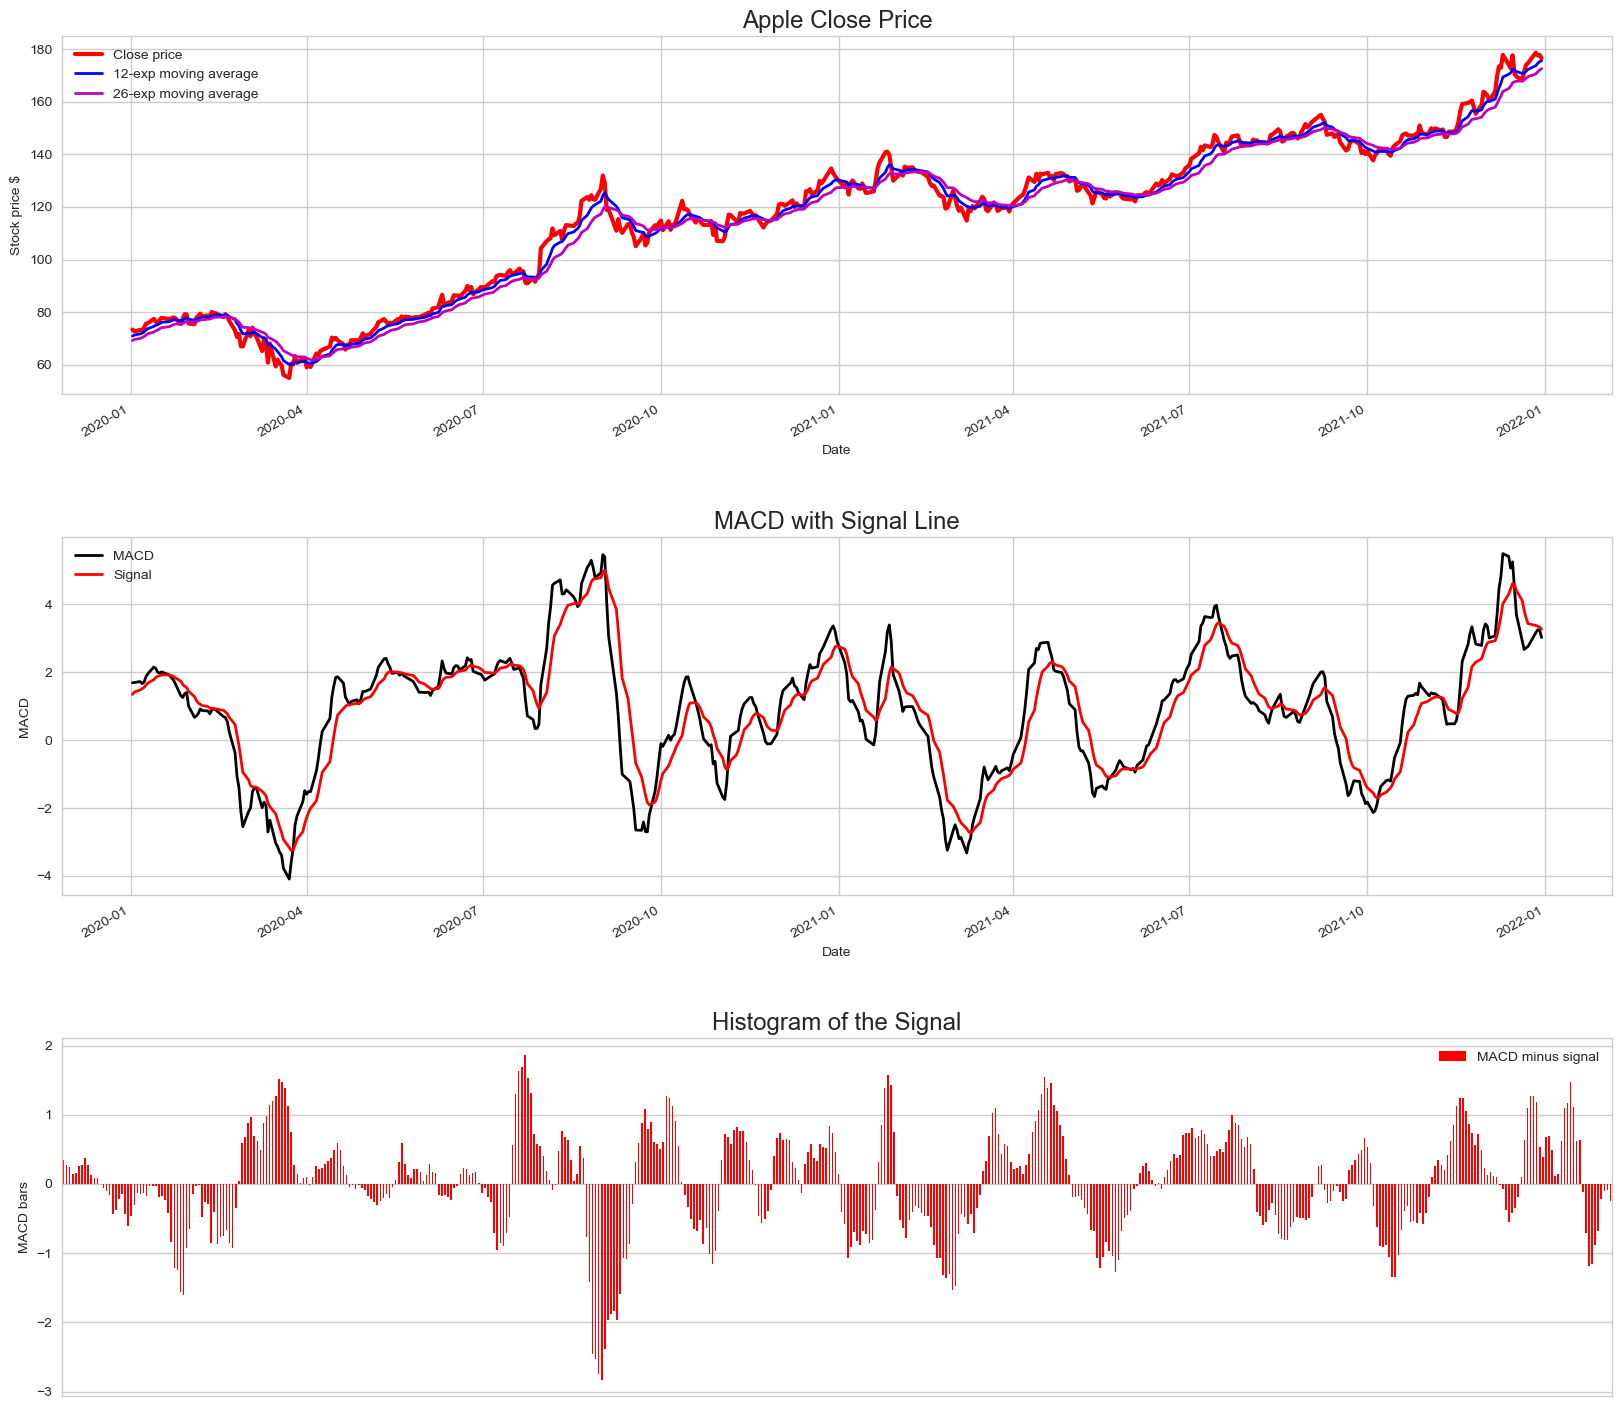

In [ ]:
#compute macd withoptimal values
short_window_macd_op=8
long_widnow_macd_op=17
signal_periods_op=9

#compute plot for the signal
apple_signal=signal_0(df_prices[tickers[0]],short_window=short_window_macd_op,long_window=long_widnow_macd_op,signal_period=signal_periods_op)
apple_signal

start_date = '2020-01-01'
end_date = '2021-12-31'
apple_signal=apple_signal.loc[start_date:end_date]

plt.style.use('seaborn')
plt.style.use('seaborn-whitegrid')

short_period_macd = 12
long_period_macd = 26


#plot the prices with the short and long EWM
fig = plt.figure(figsize=(20,20))
ax1=fig.add_subplot(311, ylabel='Stock price $')
apple_signal['prices'].plot(ax=ax1,color='r',lw=3,label='Close price',legend=True)
apple_signal['short_ma'].plot(ax=ax1,color='b',lw=2,label=str(short_period_macd)+'-exp moving average',legend=True)
apple_signal['long_ma'].plot(ax=ax1,color='m',lw=2,label=str(long_period_macd)+'-exp moving average',legend=True)
ax1.set_title('Apple Close Price', fontsize = 'xx-large')
#plt.xlim(['2018-01-01','2021-12-31'])
plt.subplots_adjust(hspace=0.4)

#plot the MACD with the signal
ax2=fig.add_subplot(312, ylabel='MACD')
ax2.set_title('MACD with Signal Line', fontsize = 'xx-large')
apple_signal['MADC'].plot(ax=ax2,color='k',lw=2,label='MACD',legend=True)
apple_signal['signal'].plot(ax=ax2,color='r',lw=2,label='Signal',legend=True)
ax1.set_title('Apple Close Price', fontsize = 'xx-large')

#plt.xlim(['2018-01-01','2021-12-31'])

#plot the histogram of holding and selling phases
ax3=fig.add_subplot(313, ylabel='MACD bars')
ax3.set_title('Histogram of the Signal', fontsize = 'xx-large')
x_axis = ax3.axes.get_xaxis()
x_axis.set_visible(False)
apple_signal['histogram'].plot(ax=ax3,color='r', kind='bar',label='MACD minus signal', legend=True,use_index=False)



### 3.2.2 RSI

C:\Users\janik\AppData\Local\Temp\ipykernel_2776\3325590351.py:22: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
C:\Users\janik\AppData\Local\Temp\ipykernel_2776\3325590351.py:23: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


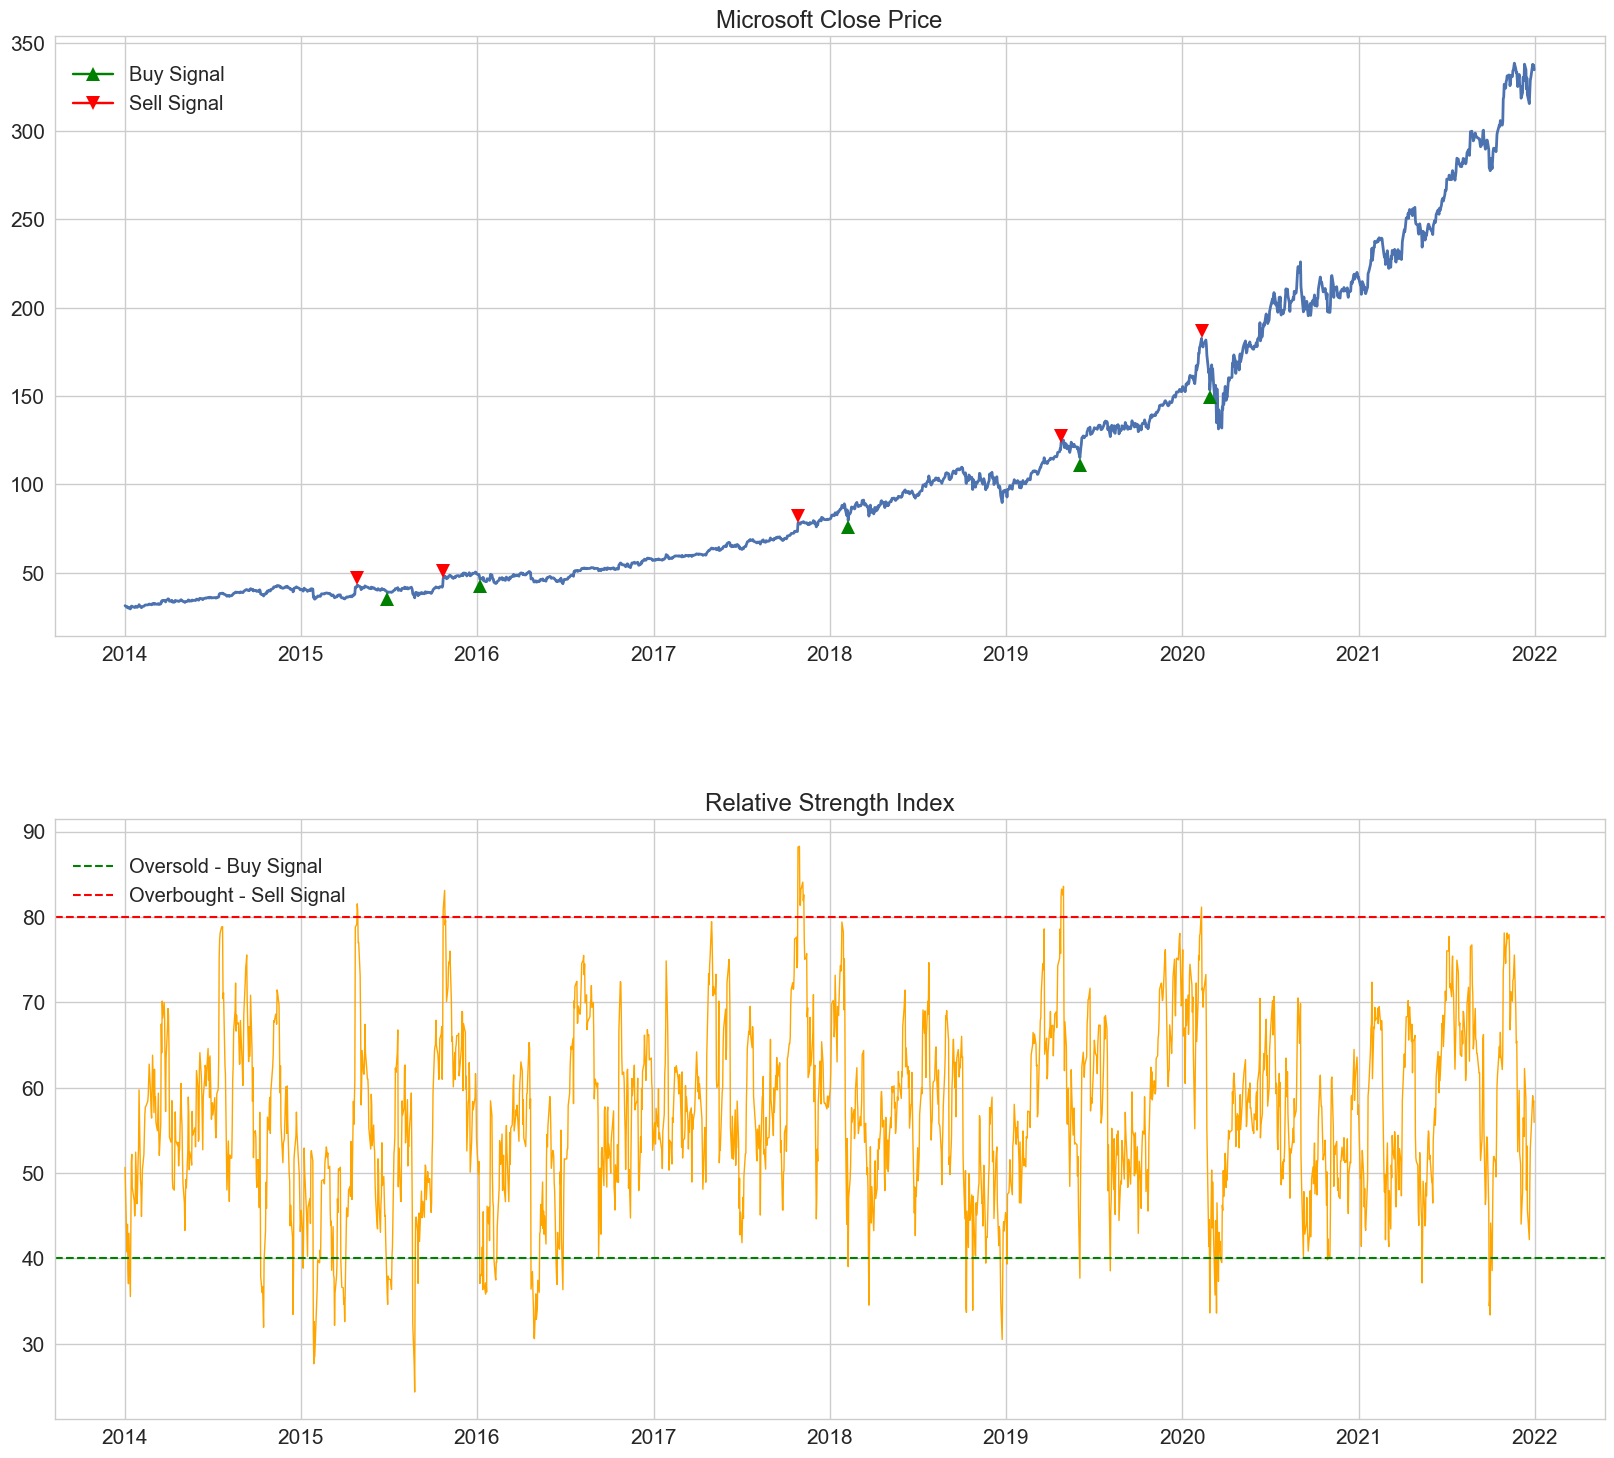

In [ ]:
# Setting up the data for the plots
RSI_data = signal_1(df_prices[tickers[1]], window = 21, upper_bound = 80, lower_bound = 40)

## Include the buy and sell price in my data frame
RSI_data['buy price'] = np.nan
RSI_data['sell price'] = np.nan

# Set 'buy price' values based on conditions that position_change is equal to 1
RSI_data.loc[RSI_data['position_change'] == 1, 'buy price'] = RSI_data['Close Price']

# Set 'sell price' values based on conditions that position_change is equal to -1
RSI_data.loc[RSI_data['position_change'] == -1, 'sell price'] = RSI_data['Close Price']

# Define the start and end date for the timeframe to be plotted
start_date = '2014-01-01'
end_date = '2021-12-31'

# Filter the data based on the specified timeframe
filtered_data = RSI_data.loc[(RSI_data.index >= start_date) & (RSI_data.index <= end_date)]

# Set the theme of our chart
plt.style.use('seaborn')
plt.style.use('seaborn-whitegrid')

# Make our resulting figure much bigger
plt.rcParams['figure.figsize'] = (20, 20)

# Create two charts on the same figure.
ax1 = plt.subplot2grid((10,1), (0,0), rowspan = 4, colspan = 1)
ax2 = plt.subplot2grid((10,1), (5,0), rowspan = 4, colspan = 1)

# Set the Marker Offset -> the higher the number the further are the markers away from the trendline
marker_offset = 6

# First chart:
# Plot the closing price on the first chart
ax1.plot(filtered_data['Close Price'], linewidth=2)
ax1.plot(filtered_data.index, filtered_data['buy price'] - marker_offset , marker = '^', markersize = 10, color = 'green', label = 'Buy Signal')
ax1.plot(filtered_data.index, filtered_data['sell price'] + marker_offset , marker = 'v', markersize = 10, color = 'red', label = 'Sell Signal')
ax1.set_title('Microsoft Close Price', fontsize = 'xx-large')
ax1.legend(fontsize = 'x-large', loc = 'upper left', bbox_to_anchor=(0.00, 0.98))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)


# Second chart
# Plot the RSI
ax2.set_title('Relative Strength Index', fontsize = 'xx-large')
ax2.plot(filtered_data['rsi_values'], color='orange', linewidth=1)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)

# Add two horizontal lines, signalling the buy and sell ranges.
# Oversold
ax2.axhline(40, linestyle='--', linewidth=1.5, color='green', label = 'Oversold - Buy Signal')
# Overbought
ax2.axhline(80, linestyle='--', linewidth=1.5, color='red', label = 'Overbought - Sell Signal')
ax2.legend(fontsize = 'x-large', loc = 'upper left', bbox_to_anchor=(0.00, 0.965))


### 3.2.3 Bollinger Bands

C:\Users\janik\AppData\Local\Temp\ipykernel_2776\1424868102.py:19: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
C:\Users\janik\AppData\Local\Temp\ipykernel_2776\1424868102.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


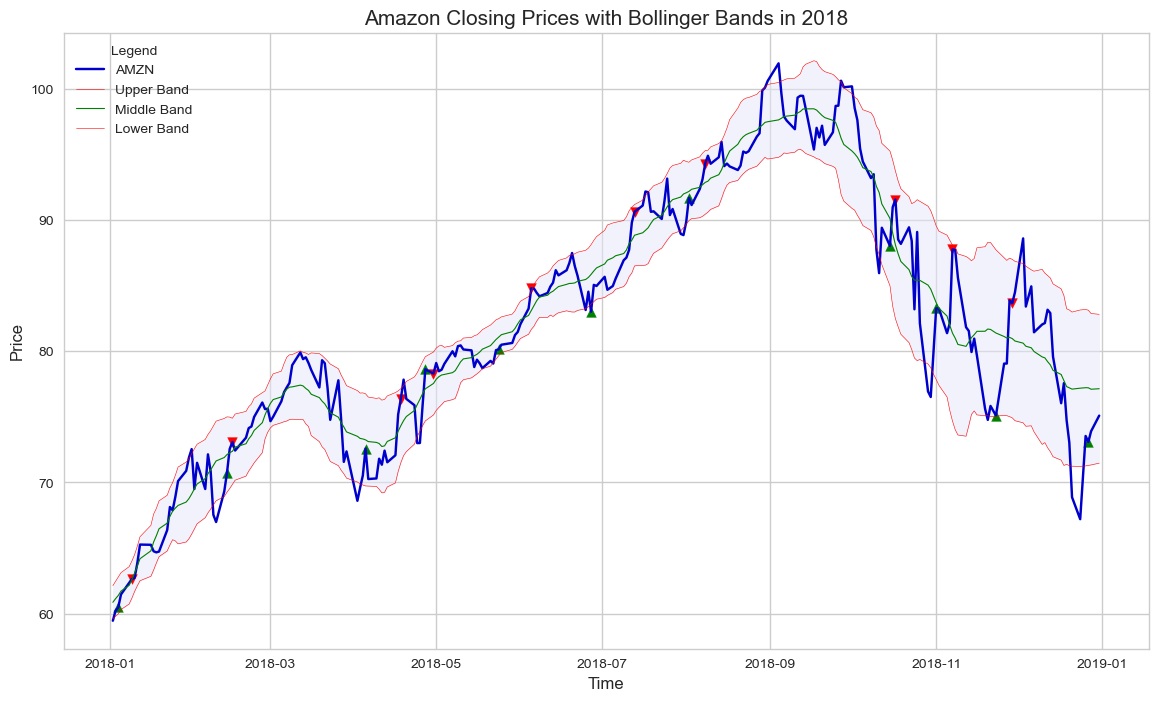

In [ ]:
#### Building graphs with data and further introduce the performance statistics 
#### downside simple moving average, Bollinger upper band and Bollinger lower band

# Get the Bollinger Bands signal for the Amazon stock
amzn_signal = signal_2(df_prices[tickers[2]],window_length=21,num_std=1.5)

# Create a new figure
plt.figure(figsize=(14,8))

# Shorter time frame for visualization
start_date = '2018-01-01'
end_date = '2018-12-31'

# Select the slice of data for the period
df_prices_slice = df_prices.loc[start_date:end_date]
amzn_signal_slice = amzn_signal.loc[start_date:end_date]

# Set the theme of our chart
plt.style.use('seaborn')
plt.style.use('seaborn-whitegrid')

# Plot the price
plt.plot(df_prices_slice['AMZN'], label = 'AMZN', color = 'mediumblue')

# Plot the bands
plt.plot(amzn_signal_slice['Upper Band'], label = 'Upper Band', color = 'red', linewidth = 0.4)
plt.plot(amzn_signal_slice['Middle Band'], label = 'Middle Band', color = 'green', linewidth = 0.8)
plt.plot(amzn_signal_slice['Lower Band'], label = 'Lower Band', color = 'red', linewidth = 0.4)

# Fill the area between the bands
plt.fill_between(amzn_signal_slice.index, amzn_signal_slice['Upper Band'], amzn_signal_slice['Lower Band'], color = 'lavender', alpha = 0.5)

# Add scatter markers for opening and closing positions
open_positions = amzn_signal_slice[amzn_signal_slice['position_change'] == 1]
close_positions = amzn_signal_slice[amzn_signal_slice['position_change'] == -1]
plt.scatter(open_positions.index, df_prices_slice.loc[open_positions.index, 'AMZN'], color = 'green', marker = '^', alpha = 1)
plt.scatter(close_positions.index, df_prices_slice.loc[close_positions.index, 'AMZN'], color = 'red', marker = 'v', alpha = 1)

# Labels and legend
plt.title('Amazon Closing Prices with Bollinger Bands in 2018', fontsize = 15)
plt.xlabel('Time', fontsize = 12)
plt.ylabel('Price', fontsize = 12)
plt.legend(title='Legend', loc = 'upper left')
plt.grid(True)

# Show the plot
plt.show()